# Working with TIF Files in Python
### Reading, exploring, and analyzing multiplexed imaging data

**Topics (~30 min):**
1. Loading TIFs — array shapes for multilayer vs. single-layer files
2. Reading XML/OME metadata to get channel names
3. Extracting a list of cell segments — **two approaches**
   - A. MIBI-style: pixel-label segmentation mask
   - B. Xenium-style: OME-TIFF with `is_ome=True`
4. Generating tissue region masks and assigning cells to regions

---

In [1]:
import numpy as np
import tifffile
import skimage.io as skio
import skimage.measure
import skimage.morphology as morph
import scipy.ndimage as ndi
import shapely.geometry as geom
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

In [2]:
# -------------------------------------------------------------------
# Demo data paths  (adjust root_dir to wherever data_demo lives)
# -------------------------------------------------------------------
import os
root_dir = "../data_demo"   # relative to this notebook; change if needed

# MIBI data
MIBI_MARKER_TIF = os.path.join(root_dir, "MIBI Campbell Cancer Disc 2026",
                               "PT0550-080218-BX_ROI1.tiff")
MIBI_SEG_TIF    = os.path.join(root_dir, "MIBI Campbell Cancer Disc 2026",
                               "PT0550_080218-BX_ROI1_expanded_full_mask.tif")

# Xenium morphology_focus data (10x Genomics OME-TIFF)
XENIUM_DIR      = os.path.join(root_dir,
                               "Xenium_Prime_Breast_Cancer_FFPE_xe_outs",
                               "morphology_focus")
XENIUM_TIF      = os.path.join(XENIUM_DIR, "morphology_focus_0000.ome.tif")
# -------------------------------------------------------------------

---
## 1. Loading TIFs — multilayer vs. single-layer

Multiplexed imaging produces **multilayer TIFs**: one image layer ("page") per marker channel, all stacked into a single file.  
Segmentation files are typically **single-layer**: each pixel holds an integer cell ID (0 = background).

There are also **OME-TIFFs** (Open Microscopy Environment), which embed rich XML metadata and can be pyramidal (multiple resolution levels) and multi-file. Xenium morphology_focus images use this format.

| Format | Reading function | Returns |
|---|---|---|
| MIBI multilayer TIF | `skio.imread_collection(..., plugin="tifffile")` | collection of 2-D arrays |
| MIBI segmentation (single-layer) | `skio.imread(..., plugin="tifffile")` | one 2-D array of integer IDs |
| Xenium OME-TIFF (all channels, full res) | `tifffile.imread(..., is_ome=True, level=0)` | 3-D array (channels × H × W) |
| Xenium OME-TIFF (one channel, any res) | `tifffile.imread(..., is_ome=False, level=N)` | 2-D array |

In [3]:
# ── MIBI: multilayer marker stack ──────────────────────────────────
marker_imstack = skio.imread_collection(MIBI_MARKER_TIF, plugin="tifffile")

print("Type:", type(marker_imstack))
print("Shape of full stack (channels, rows, cols):", marker_imstack[0].shape)
print("Shape of a single channel:              ", marker_imstack[0][0].shape)
print("Data type:", marker_imstack[0].dtype)

/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/1233038552.py:2: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread_collection`.
  marker_imstack = skio.imread_collection(MIBI_MARKER_TIF, plugin="tifffile")


Type: <class 'skimage.io.collection.ImageCollection'>
Shape of full stack (channels, rows, cols): (33, 2048, 2048)
Shape of a single channel:               (2048, 2048)
Data type: float32


In [4]:
# ── MIBI: single-layer segmentation mask ───────────────────────────
seg = skio.imread(MIBI_SEG_TIF, plugin="tifffile")

print("Type:", type(seg))
print("Shape (rows, cols):", seg.shape)           # 2-D — no channel dimension
print("Data type:", seg.dtype)                    # uint16 or uint32
print("Max pixel value (= number of cells):", seg.max())

Type: <class 'numpy.ndarray'>
Shape (rows, cols): (2048, 2048)
Data type: uint16
Max pixel value (= number of cells): 5715


/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/1422611565.py:2: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  seg = skio.imread(MIBI_SEG_TIF, plugin="tifffile")


Downsampled shape (rows, cols): (37472, 25632)
Data type: uint16


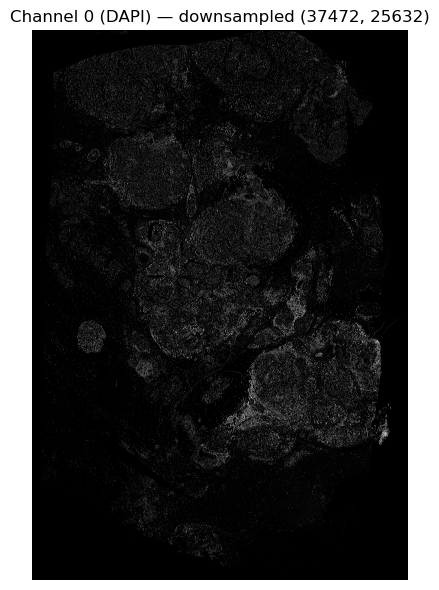

In [5]:
# ── Xenium: explore quickly ─────────────────────
# 
# AVOID: tifffile.TiffFile(f).asarray() → tries to load all ~2 GB into RAM
# USE:   tifffile.imread() with is_ome=False and a downsampled level
#
# The morphology_focus files are pyramidal TIFFs — each file contains
# the same image at multiple resolutions (level 0 = full res, level 1 = 2x smaller, etc.)
# For a quick look, always start at level 1 or 2.

downsampled_ch0 = tifffile.imread(XENIUM_TIF, is_ome=False, level=1)

print("Downsampled shape (rows, cols):", downsampled_ch0.shape)
print("Data type:", downsampled_ch0.dtype)

plt.figure(figsize=(6, 6))
plt.imshow(downsampled_ch0, cmap="gray")
plt.title(f"Channel 0 (DAPI) — downsampled {downsampled_ch0.shape}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# ── Xenium: all channels, full resolution ─────────────────────────
# is_ome=True tells tifffile to follow the OME-XML cross-file references
# and load all 4 channel files as one array.
# level=0 is the only level supported in multi-file OME mode.
#
# ⚠ The warning "OME series cannot read multi-file pyramids" is EXPECTED —
#   it just means pyramid levels > 0 are unavailable in this mode.
# ⚠ This loads ~8 GB total; skip on a memory-limited machine.

# xenium_img = tifffile.imread(XENIUM_TIF, is_ome=True, level=0, aszarr=False)
# print("Shape (channels, rows, cols):", xenium_img.shape)
# n_ch = xenium_img.shape[0]

# For the demo we read n_ch from the OME-XML instead (fast, no data loaded)
import xml.etree.ElementTree as ET
with tifffile.TiffFile(XENIUM_TIF) as tif:
    root = ET.fromstring(tif.ome_metadata)
ns = {"ome": "http://www.openmicroscopy.org/Schemas/OME/2016-06"}
n_ch = len(root.findall(".//ome:Channel", ns))
print(f"Number of channels (from XML): {n_ch}")

Number of channels (from XML): 4


Channel files found:
  morphology_focus_0000.ome.tif
  morphology_focus_0001.ome.tif
  morphology_focus_0002.ome.tif
  morphology_focus_0003.ome.tif


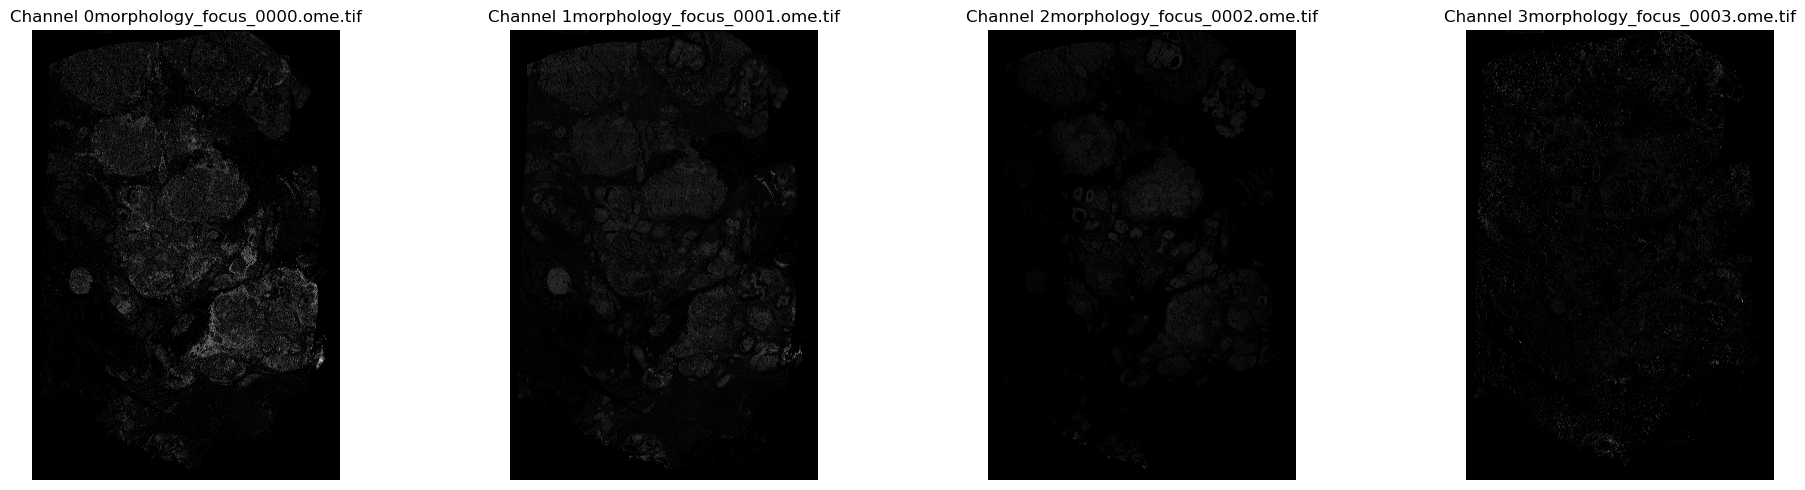

In [7]:
# ── Plot all channels — load each file individually at level 1 ────
# morphology_focus_000N.ome.tif each hold one channel at full+pyramid res.
# With is_ome=False we load just that file, at any pyramid level, instantly.

import glob, os
channel_files = sorted(glob.glob(os.path.join(XENIUM_DIR, "*.ome.tif")))
print("Channel files found:")
for f in channel_files:
    print(" ", os.path.basename(f))

fig, axes = plt.subplots(1, len(channel_files), figsize=(5 * len(channel_files), 5), squeeze=False)
for i, fpath in enumerate(channel_files):
    img = tifffile.imread(fpath, is_ome=False, level=1)   # fast — downsampled
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"Channel {i}{os.path.basename(fpath)}")
    axes[0, i].axis("off")
plt.tight_layout()
plt.show()

Page shape: (74945, 51265)
Page dtype: uint16
Crop shape: (1000, 1000)


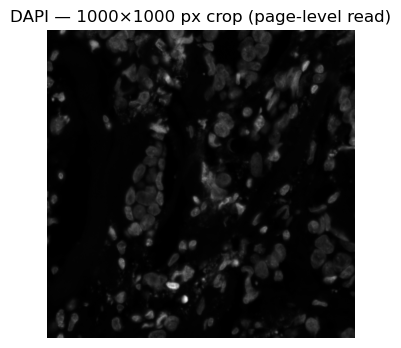

In [8]:
# ── Summary: three loading patterns and their trade-offs ──────────
#
# 1) Quick preview (one channel, downsampled)    → is_ome=False, level=1
#    tifffile.imread(XENIUM_TIF, is_ome=False, level=1)
#    → 2-D array, loads in seconds
#
# 2) All channels, full resolution               → is_ome=True, level=0
#    tifffile.imread(XENIUM_TIF, is_ome=True, level=0, aszarr=False)
#    → 3-D array (n_ch, H, W), loads ALL ~8 GB — slow
#
# 3) Lazy / memory-mapped (best for large data)  → aszarr=True
#    Requires zarr v3:  pip install "zarr>=3"
#    store = tifffile.imread(XENIUM_TIF, is_ome=True, level=0, aszarr=True)
#    import zarr; z = zarr.open(store)           # nothing loaded yet
#    crop = z[0, 1000:2000, 1000:2000]           # load only what you slice

# ── Working alternative: read a single tile/crop via page-level access ──
# tifffile gives direct access to individual pages without loading the
# whole file. Reading one page still loads that full 2-D layer, but
# we can immediately slice it to a crop of interest.

with tifffile.TiffFile(XENIUM_TIF) as tif:
    # tif.pages[0] is channel 0 (DAPI) at full resolution
    page = tif.pages[0]
    print("Page shape:", page.shape)
    print("Page dtype:", page.dtype)
    # Read the full page then immediately slice — avoids holding the whole
    # array in memory any longer than necessary
    crop = page.asarray()[5000:6000, 5000:6000]

print("Crop shape:", crop.shape)
plt.figure(figsize=(4, 4))
plt.imshow(crop, cmap="gray")
plt.title("DAPI — 1000×1000 px crop (page-level read)")
plt.axis("off")
plt.show()

---
## 2. Reading metadata — getting channel/marker names

### 2a. MIBI: `PageName` tags in the TIFF IFD

MIBI TIFs embed per-page metadata in standard TIFF tags. `tifffile` exposes these through
`tif.pages[i].tags['PageName'].value`.  
The value usually looks like `"CD8 (Opal 570)"` — we keep only the part before the parenthesis.

In [9]:
marker_list = []

with tifffile.TiffFile(MIBI_MARKER_TIF) as tif:
    print(f"Total pages (channels): {len(tif.pages)}")
    print()
    for i, page in enumerate(tif.pages):
        raw_name   = page.tags['PageName'].value
        clean_name = raw_name.split(' (', 1)[0]
        marker_list.append(clean_name)
        print(f"  Layer {i:2d}: {raw_name!r:45s} → '{clean_name}'")

print(f"\nFinal marker list:\n{marker_list}")

Total pages (channels): 33

  Layer  0: 'Beta-tubulin (113)'                          → 'Beta-tubulin'
  Layer  1: 'CD11b (155)'                                 → 'CD11b'
  Layer  2: 'CD11c (144)'                                 → 'CD11c'
  Layer  3: 'CD138 (174)'                                 → 'CD138'
  Layer  4: 'CD14 (154)'                                  → 'CD14'
  Layer  5: 'CD163 (142)'                                 → 'CD163'
  Layer  6: 'CD20 (167)'                                  → 'CD20'
  Layer  7: 'CD3 (159)'                                   → 'CD3'
  Layer  8: 'CD31 (152)'                                  → 'CD31'
  Layer  9: 'CD4 (143)'                                   → 'CD4'
  Layer 10: 'CD45 (175)'                                  → 'CD45'
  Layer 11: 'CD45RO (161)'                                → 'CD45RO'
  Layer 12: 'CD56 (151)'                                  → 'CD56'
  Layer 13: 'CD68 (156)'                                  → 'CD68'
  Layer 14: 'CD8 (158)

In [33]:
# Look up a channel by name
def get_channel(name):
    """Return the 2-D image array for a given MIBI marker name."""
    return marker_imstack[0][marker_list.index(name)]

# Example
print("dsDNA layer:", get_channel("dsDNA").shape)

dsDNA layer: (2048, 2048)


### Note: Sometimes the metadata is harder to find...

Depending on the source of the file, it may not be immediately clear which channel is which. This example is from a Vectra QPTIFF file.

In [11]:
# tmp_QPTIF = "/Users/katiecampbell/trainees/elieberman/vectra/ACTVAC #82 C4M4 - KUP 041626_Scan1.qptiff"
with tifffile.TiffFile(tmp_QPTIF) as tif:
    print(f"Total pages (channels): {len(tif.pages)}")
    for i, page in enumerate(tif.pages):
        print(i)
        raw_name   = page.tags#['PageName'].value
        print(raw_name)

Total pages (channels): 51
0
TiffTag 254 NewSubfileType @24 LONG @36 = UNDEFINED
TiffTag 256 ImageWidth @44 SHORT @56 = 44160
TiffTag 257 ImageLength @64 SHORT @76 = 59040
TiffTag 258 BitsPerSample @84 SHORT @96 = 8
TiffTag 259 Compression @104 SHORT @116 = LZW
TiffTag 262 PhotometricInterpretation @124 SHORT @136 = MINISBLACK
TiffTag 270 ImageDescription @144 ASCII[86980] @161964 = <?xml version="1.0" en
TiffTag 277 SamplesPerPixel @164 SHORT @176 = 1
TiffTag 282 XResolution @184 RATIONAL @196 = (4294967295, 107380)
TiffTag 283 YResolution @204 RATIONAL @216 = (4294967295, 107380)
TiffTag 284 PlanarConfiguration @224 SHORT @236 = CONTIG
TiffTag 286 XPosition @244 RATIONAL @256 = (3110402559, 4294967295)
TiffTag 287 YPosition @264 RATIONAL @276 = (4294967295, 1196523112)
TiffTag 296 ResolutionUnit @284 SHORT @296 = CENTIMETER
TiffTag 305 Software @304 ASCII[16] @248944 = PerkinElmer-QPI
TiffTag 306 DateTime @324 ASCII[20] @248960 = 2026:05:01 10:29:19
TiffTag 322 TileWidth @344 SHORT @

### 2b. Xenium: OME-XML embedded in the first file

Xenium OME-TIFFs store channel information in an XML block attached to the first page of
`morphology_focus_0000.ome.tif`. Each `<Channel>` element has a `Name` attribute.
The four Xenium morphology channels are: DAPI, 18S rRNA, ATP1A1/CD45/E-Cadherin, and Interior RNA.

In [12]:
import xml.etree.ElementTree as ET

with tifffile.TiffFile(XENIUM_TIF) as tif:
    ome_xml = tif.ome_metadata          # raw XML string

# Parse channel names
ns = {'ome': 'http://www.openmicroscopy.org/Schemas/OME/2016-06'}
root = ET.fromstring(ome_xml)

xenium_channels = []
for ch in root.findall('.//ome:Channel', ns):
    name = ch.get('Name', f"Channel_{ch.get('ID')}")
    xenium_channels.append(name)
    print(f"  {ch.get('ID'):20s}  Name: {name}")

print(f"\nXenium channel list: {xenium_channels}")

  Channel:0             Name: DAPI
  Channel:1             Name: ATP1A1/CD45/E-Cadherin
  Channel:2             Name: 18S
  Channel:3             Name: alphaSMA/Vimentin

Xenium channel list: ['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'alphaSMA/Vimentin']


---
## 3. Extracting a list of cell segments — two approaches

A **segment** is one segmented cell: a set of pixels that all belong to the same cell, identified
by a unique integer ID.

The two data formats encode segments differently:

| | MIBI (pixel-label mask) | Xenium (zarr output bundle) |
|---|---|---|
| Where segments live | In the segmentation TIF — each pixel value **is** the cell ID | `cells.zarr.zip` — arrays for IDs, centroids, area, and boundary polygons |
| Key read function | `skio.imread()` | `zarr.ZipStore()` + `zarr.open_group()` |
| Getting IDs | `np.unique(seg_array)` | `cells_z["cell_id"][:]` |
| Getting centroids/area | `skimage.measure.regionprops(seg)` | `cells_z["cell_summary"][:]` |
| Getting boundaries | `np.where(seg == cell_id)` | `cells_z["polygon_sets/1/vertices"][:]` |

### Example A — MIBI: segment IDs from a pixel-label mask

In [34]:
seg

array([[   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       ...,
       [   0,    0, 5657, ...,    0,    0,    0],
       [   0,    0, 5657, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0]], dtype=uint16)

In [13]:
# seg was loaded earlier with skio.imread()
# Each unique non-zero integer is one cell

all_ids = np.unique(seg)           # sorted array of every unique pixel value
print("Unique values (first 10):", all_ids[:10])
print("Value 0 = background")

segment_ids = all_ids[all_ids > 0]  # drop background
print(f"\nTotal segments (cells): {len(segment_ids)}")
print("First 10 IDs:", segment_ids[:10])

Unique values (first 10): [0 1 2 3 4 5 6 7 8 9]
Value 0 = background

Total segments (cells): 5715
First 10 IDs: [ 1  2  3  4  5  6  7  8  9 10]


Median cell area: 353 px
Min / max cell area: 15 / 1622 px


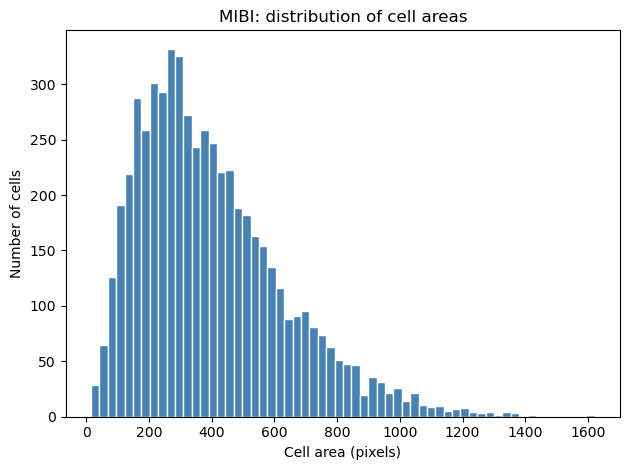

In [14]:
# For each segment: how many pixels does it occupy?
# np.bincount is the fast vectorised way — much quicker than looping over IDs
pixel_counts = np.bincount(seg.ravel())     # index = cell ID, value = pixel count
# Drop index 0 (background)
cell_areas = pixel_counts[1:]
print(f"Median cell area: {np.median(cell_areas):.0f} px")
print(f"Min / max cell area: {cell_areas.min()} / {cell_areas.max()} px")

plt.hist(cell_areas, bins=60, color="steelblue", edgecolor="white")
plt.xlabel("Cell area (pixels)")
plt.ylabel("Number of cells")
plt.title("MIBI: distribution of cell areas")
plt.tight_layout()
plt.show()

In [15]:
# For each segment: centroid (x, y)
# skimage.measure.regionprops is the clean way to get this for all cells at once
props = skimage.measure.regionprops(seg)   # one object per segment, ordered by label

cells_mibi = pd.DataFrame({
    "segment_id": [p.label              for p in props],
    "area_px":    [p.area               for p in props],
    "centroid_y": [p.centroid[0]        for p in props],  # row
    "centroid_x": [p.centroid[1]        for p in props],  # col
})

print(cells_mibi.shape)
cells_mibi.head()

(5715, 4)


,segment_id,area_px,centroid_y,centroid_x
0,1,63.0,2.111111,1697.587302
1,2,31.0,1.387097,1716.129032
2,3,64.0,2.484375,1065.921875
3,4,147.0,3.115646,1149.346939
4,5,59.0,2.694915,1345.864407


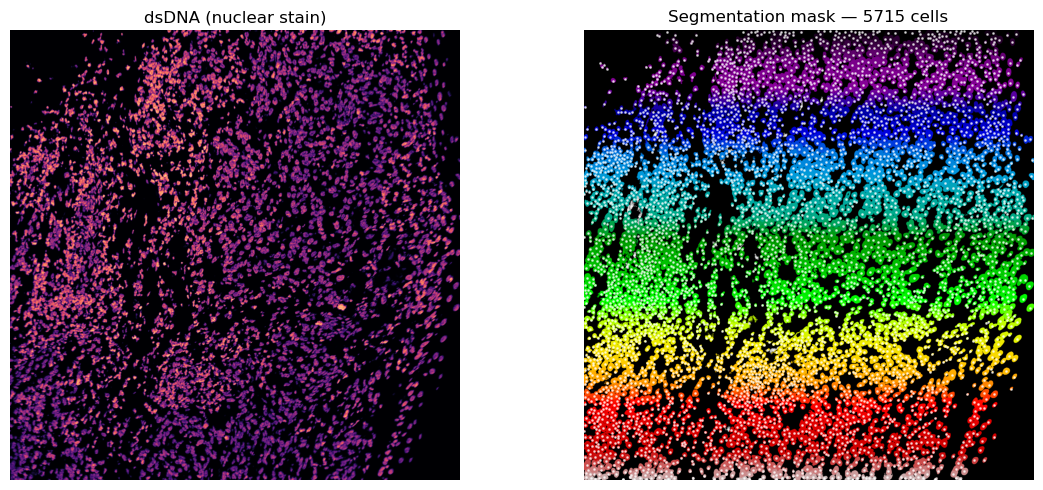

In [16]:
# Visualise segmentation — each cell coloured differently
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(get_channel("dsDNA"), cmap="magma")
axes[0].set_title("dsDNA (nuclear stain)")
axes[0].axis("off")

axes[1].imshow(seg, cmap="nipy_spectral")
axes[1].scatter(cells_mibi["centroid_x"], cells_mibi["centroid_y"],
                s=1, c="white", alpha=0.6)
axes[1].set_title(f"Segmentation mask — {len(cells_mibi)} cells")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Example B — Xenium: segment information from `cells.zarr.zip`

In the Xenium output, the **morphology_focus** OME-TIFF is the *image* (DAPI + morphology stains).
It does **not** contain cell ID labels per pixel.
Cell segmentation results are stored in `cells.zarr.zip`, which contains:

| Array | Shape | Contents |
|---|---|---|
| `cell_id` | (n_cells, 2) uint32 | Cell ID per cell |
| `cell_summary` | (n_cells, 8) float64 | Centroid x/y, cell area, nucleus centroid x/y, nucleus area, z_level, nucleus count |
| `polygon_sets/0/vertices` | (n_nuclei, 50) float32 | Nucleus boundary vertices — up to 25 (x, y) pairs per nucleus |
| `polygon_sets/1/vertices` | (n_cells, 50) float32 | Cell boundary vertices — up to 25 (x, y) pairs per cell |
| `polygon_sets/N/num_vertices` | (n_cells,) int32 | Number of valid vertex pairs for each polygon |

Open with `zarr.ZipStore` — this works with **zarr v2** (the version in the squidpy-env).

In [17]:
import zarr

XENIUM_CELLS_ZARR = os.path.join(
    root_dir,
    "Xenium_Prime_Breast_Cancer_FFPE_xe_outs",
    "cells.zarr.zip"
)

# Open with zarr v2 ZipStore — reads metadata only, no data loaded yet
store   = zarr.ZipStore(XENIUM_CELLS_ZARR, mode="r")
cells_z = zarr.open_group(store, mode="r")

print("Top-level keys:", list(cells_z.keys()))
print("Total cells (from .zattrs):", cells_z.attrs["number_cells"])
print("Polygon sets:", cells_z.attrs["polygon_set_display_names"])
print()

# Load cell IDs and summary statistics into numpy arrays
cell_ids     = cells_z["cell_id"][:]          # shape (n_cells, 2) — col 0 is the cell ID
cell_summary = cells_z["cell_summary"][:]     # shape (n_cells, 8) float64
col_names    = list(cells_z["cell_summary"].attrs["column_names"])

# Build a tidy DataFrame
cells_xenium = pd.DataFrame(cell_summary, columns=col_names)
cells_xenium.insert(0, "cell_id", cell_ids[:, 0])

print(f"Total cells: {len(cells_xenium)}")
print(f"Columns: {list(cells_xenium.columns)}")
cells_xenium.head()

Top-level keys: ['cell_id', 'cell_summary', 'masks', 'polygon_sets']
Total cells (from .zattrs): 699110
Polygon sets: ['Nucleus boundaries', 'Cell boundaries']

Total cells: 699110
Columns: ['cell_id', 'cell_centroid_x', 'cell_centroid_y', 'cell_area', 'nucleus_centroid_x', 'nucleus_centroid_y', 'nucleus_area', 'z_level', 'nucleus_count']


,cell_id,cell_centroid_x,cell_centroid_y,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count
0,3701,1100.902710,1684.727905,220.723758,1101.160034,1682.970947,108.871723,0.0,1.0
1,6889,1115.280884,1698.792114,363.914232,1112.247070,1706.100098,91.892972,0.0,2.0
2,21595,1111.883667,1687.348877,181.392663,1112.448730,1686.955200,114.155004,0.0,1.0
3,30108,1107.006836,1717.586548,279.426885,1112.322021,1718.700195,81.010315,0.0,2.0
4,30990,1121.226929,1726.981689,75.094846,1120.330688,1727.555054,52.607033,0.0,1.0


In [18]:
# ── Read cell boundary polygons from polygon_sets/1 ───────────────
# polygon_sets/0 = nucleus boundaries
# polygon_sets/1 = cell boundaries  <- we want this one
#
# vertices: shape (n_cells, 50) float32
#   Up to 25 (x, y) pairs stored flat: [x0, y0, x1, y1, ..., x24, y24]
# num_vertices: how many (x, y) pairs are valid for each polygon
# Coordinates are in microns in the Xenium tissue coordinate system.

vertices  = cells_z["polygon_sets/1/vertices"][:]      # (n_cells, 50) float32
num_verts = cells_z["polygon_sets/1/num_vertices"][:]  # (n_cells,)    int32

print(f"vertices shape:              {vertices.shape}")
print(f"num_vertices range: {num_verts.min()} - {num_verts.max()} vertex pairs per polygon")

# Build Shapely Polygons — indexed by cell_id for easy lookup later
xenium_polys = {}
for i in range(len(num_verts)):
    n   = num_verts[i]
    cid = cell_ids[i, 0]
    if n < 3:
        continue                               # degenerate polygon, skip
    xy = vertices[i, :n * 2].reshape(n, 2)    # (n, 2) array of (x, y) micron coords
    xenium_polys[cid] = geom.Polygon(xy)

xenium_segment_ids = list(xenium_polys.keys())
print(f"\nTotal cell polygons built: {len(xenium_polys)}")
print("First 5 cell IDs:", xenium_segment_ids[:5])

vertices shape:              (699110, 50)
num_vertices range: 8 - 25 vertex pairs per polygon

Total cell polygons built: 699110
First 5 cell IDs: [3701, 6889, 21595, 30108, 30990]


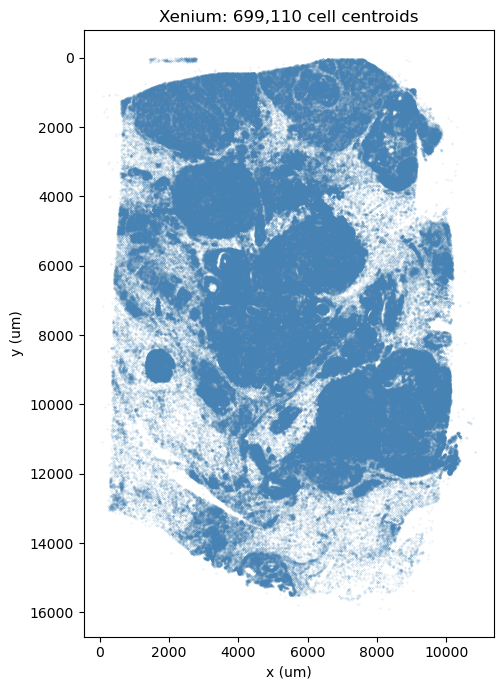

In [19]:
# ── Quick sanity check: scatter plot of cell centroids ─────────────
# cell_summary already has x/y centroids — no polygon loop needed

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    cells_xenium["cell_centroid_x"],
    cells_xenium["cell_centroid_y"],
    s=0.05, c="steelblue", alpha=0.3
)
ax.set_aspect("equal")
ax.invert_yaxis()           # Xenium y increases downward, matching image orientation
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title(f"Xenium: {len(cells_xenium):,} cell centroids")
plt.tight_layout()
plt.show()

ROI: x [5460, 5960] um   y [6925, 7425] um
Cells in ROI: 1939
Crop shape: (1176, 1177) px


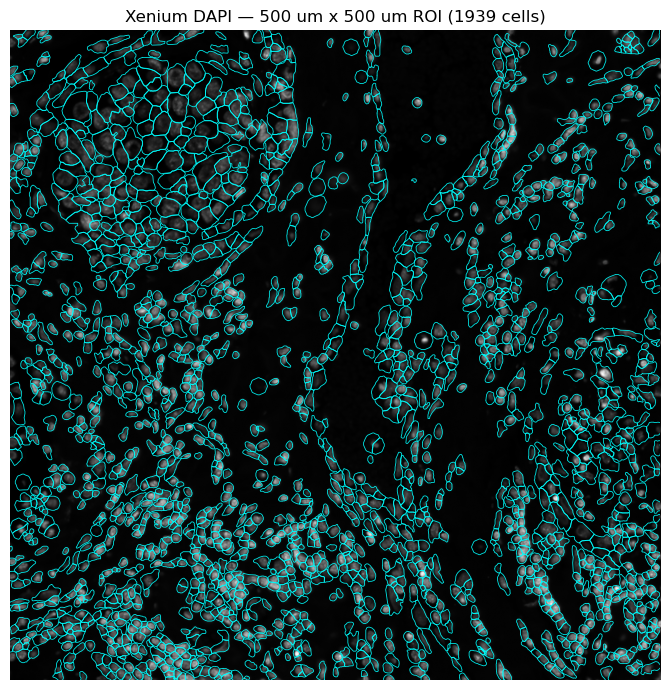

In [20]:
# ── Overlay cell boundaries on a 500 um x 500 um region ──────────
# Rather than sampling random cells across the full tissue, we:
#   1. Pick a 500 um x 500 um ROI in micron space
#   2. Filter to cells whose centroids fall inside it  (fast — just array comparison)
#   3. Build polygons only for those cells             (a few dozen, not hundreds of thousands)
#   4. Crop the DAPI image to the matching pixel region and overlay

from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

PIXEL_SIZE_FULLRES = 0.2125   # um per pixel at level 0
DOWNSAMPLE_FACTOR  = 2        # level=1 is 2x downsampled
PIXEL_SIZE_DS      = PIXEL_SIZE_FULLRES * DOWNSAMPLE_FACTOR

ROI_SIZE_UM = 500.0   # side length of region of interest in microns

# Centre the ROI on the tissue median — change x0/y0 to zoom into any region
x_med = cells_xenium["cell_centroid_x"].median()
y_med = cells_xenium["cell_centroid_y"].median()
x0, x1 = x_med - ROI_SIZE_UM / 2, x_med + ROI_SIZE_UM / 2
y0, y1 = y_med - ROI_SIZE_UM / 2, y_med + ROI_SIZE_UM / 2
print(f"ROI: x [{x0:.0f}, {x1:.0f}] um   y [{y0:.0f}, {y1:.0f}] um")

# Filter cells to those with centroids inside the ROI
in_roi = (
    cells_xenium["cell_centroid_x"].between(x0, x1) &
    cells_xenium["cell_centroid_y"].between(y0, y1)
)
roi_cells = cells_xenium[in_roi]
print(f"Cells in ROI: {len(roi_cells)}")

# Build polygons only for the ROI cells
roi_patches = []
for cid in roi_cells["cell_id"]:
    if cid not in xenium_polys:
        continue
    xy_um = np.array(xenium_polys[cid].exterior.coords)   # micron coords
    # Shift so (x0, y0) maps to pixel (0, 0) in the cropped image
    xy_um_local = xy_um - np.array([x0, y0])
    xy_px = xy_um_local / PIXEL_SIZE_DS                    # -> downsampled pixel coords
    roi_patches.append(MplPolygon(xy_px, closed=True))

# Crop the downsampled DAPI image to the ROI pixel extent
col_start = int(x0 / PIXEL_SIZE_DS)
col_end   = int(x1 / PIXEL_SIZE_DS)
row_start = int(y0 / PIXEL_SIZE_DS)
row_end   = int(y1 / PIXEL_SIZE_DS)
dapi_crop = downsampled_ch0[row_start:row_end, col_start:col_end]
print(f"Crop shape: {dapi_crop.shape} px")

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(dapi_crop, cmap="gray")
pc = PatchCollection(roi_patches, facecolor="none", edgecolor="cyan", linewidth=0.6, alpha=0.9)
ax.add_collection(pc)
ax.set_title(f"Xenium DAPI — 500 um x 500 um ROI ({len(roi_patches)} cells)")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 4. Cluster-based channel intensity analysis

Now that we have cell segments and cluster assignments, we can ask: do the morphology
channel intensities differ across clusters?

This is the bridge between **image data** (OME-TIFF pixel values) and **cell identity**
(cluster labels) — exactly the kind of question that motivates integrating TIF reading
with single-cell analysis.

Steps:
1. Load cluster assignments from `analysis.zarr.zip`
2. Sample each morphology channel at each cell's centroid pixel
3. Plot intensity histograms per channel
4. Plot per-cluster boxplots per channel
5. Select clusters of interest → build a tissue mask with dilation/erosion → export for Xenium Explorer

In [21]:
# ── Load cluster assignments from analysis.zarr.zip ────────────────
import zarr

XENIUM_ANALYSIS_ZARR = os.path.join(
    root_dir,
    "Xenium_Prime_Breast_Cancer_FFPE_xe_outs",
    "analysis.zarr.zip"
)

analysis_store = zarr.ZipStore(XENIUM_ANALYSIS_ZARR, mode="r")
analysis_z     = zarr.open_group(analysis_store, mode="r")

# group_names lives on cell_groups, not the root group
cg_attrs      = analysis_z["cell_groups"].attrs
cluster_names = cg_attrs["group_names"][0]    # level 0 = finest clustering
print(f"Clusters at level 0: {len(cluster_names)}")
print("Names:", cluster_names)
print()
print("Other available groupings:", cg_attrs["grouping_names"])

# indptr / indices use a modified CSR format:
#   indptr[k]  = end position of cluster k in the indices array
#   cluster 0 starts at index 0; cluster k starts at indptr[k-1]
indptr  = analysis_z["cell_groups/0/indptr"][:]    # shape (n_clusters,)  uint32
indices = analysis_z["cell_groups/0/indices"][:]   # shape (n_cells,)     uint32

# Build a per-cell cluster label array (1-indexed to match "Cluster 1", etc.)
cluster_labels = np.empty(len(cells_xenium), dtype=np.int32)
start = 0
for k, end in enumerate(indptr):
    cluster_labels[indices[start:int(end)]] = k + 1
    start = int(end)

cells_xenium["cluster"] = cluster_labels

# Quick count per cluster
counts = cells_xenium["cluster"].value_counts().sort_index()
print()
print("Cells per cluster:")
print(counts.to_string())

Clusters at level 0: 28
Names: ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6', 'Cluster 7', 'Cluster 8', 'Cluster 9', 'Cluster 10', 'Cluster 11', 'Cluster 12', 'Cluster 13', 'Cluster 14', 'Cluster 15', 'Cluster 16', 'Cluster 17', 'Cluster 18', 'Cluster 19', 'Cluster 20', 'Cluster 21', 'Cluster 22', 'Cluster 23', 'Cluster 24', 'Cluster 25', 'Cluster 26', 'Cluster 27', 'Cluster 28']

Other available groupings: ['gene_expression_graphclust', 'gene_expression_kmeans_2_clusters', 'gene_expression_kmeans_3_clusters', 'gene_expression_kmeans_4_clusters', 'gene_expression_kmeans_5_clusters', 'gene_expression_kmeans_6_clusters', 'gene_expression_kmeans_7_clusters', 'gene_expression_kmeans_8_clusters', 'gene_expression_kmeans_9_clusters', 'gene_expression_kmeans_10_clusters']

Cells per cluster:
cluster
0              2779
2             87981
3             57639
4             57194
5             56605
6             47417
7             47098
8             46344
9   

In [22]:
# ── Sample morphology channel intensity at each cell's centroid ────
# Strategy: load each channel file at level=1 (downsampled, fast),
# convert centroid microns -> downsampled pixel coords,
# then index the image array directly.
#
# This gives a per-cell proxy for channel intensity without rasterizing
# full polygon masks (which would be much slower).

import glob

PIXEL_SIZE_DS = 0.2125 * 2   # 0.425 um/pixel at level=1

channel_files = sorted(glob.glob(os.path.join(XENIUM_DIR, "*.ome.tif")))
channel_names = ["DAPI", "18S rRNA", "ATP1A1+CD45+E-Cad", "Interior RNA"]

# Centroid pixel coordinates (clipped to image bounds)
# Load the first channel just to get image dimensions
_img0 = tifffile.imread(channel_files[0], is_ome=False, level=1)
H_ds, W_ds = _img0.shape

col_px = (cells_xenium["cell_centroid_x"] / PIXEL_SIZE_DS).astype(int).clip(0, W_ds - 1)
row_px = (cells_xenium["cell_centroid_y"] / PIXEL_SIZE_DS).astype(int).clip(0, H_ds - 1)

for fpath, ch_name in zip(channel_files, channel_names):
    img = tifffile.imread(fpath, is_ome=False, level=1)
    cells_xenium[f"intensity_{ch_name}"] = img[row_px.values, col_px.values]
    print(f"  {ch_name}: sampled, range {img[row_px.values, col_px.values].min()} - {img[row_px.values, col_px.values].max()}")

print()
print("New columns:", [c for c in cells_xenium.columns if c.startswith("intensity")])
cells_xenium.head(3)

  DAPI: sampled, range 6 - 11056
  18S rRNA: sampled, range 0 - 10443
  ATP1A1+CD45+E-Cad: sampled, range 0 - 4768
  Interior RNA: sampled, range 0 - 10951

New columns: ['intensity_DAPI', 'intensity_18S rRNA', 'intensity_ATP1A1+CD45+E-Cad', 'intensity_Interior RNA']


,cell_id,cell_centroid_x,cell_centroid_y,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count,cluster,intensity_DAPI,intensity_18S rRNA,intensity_ATP1A1+CD45+E-Cad,intensity_Interior RNA
0,3701,1100.902710,1684.727905,220.723758,1101.160034,1682.970947,108.871723,0.0,1.0,5,1078,661,38,24
1,6889,1115.280884,1698.792114,363.914232,1112.247070,1706.100098,91.892972,0.0,2.0,5,124,923,390,40
2,21595,1111.883667,1687.348877,181.392663,1112.448730,1686.955200,114.155004,0.0,1.0,5,2073,639,37,23


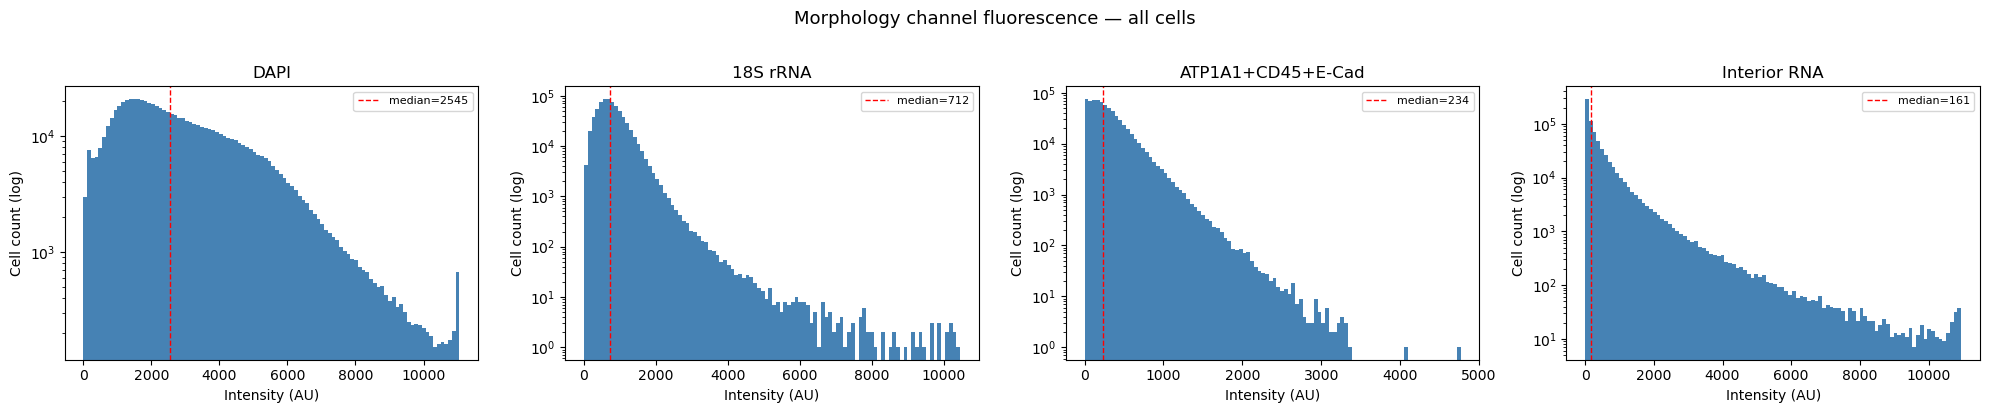

In [23]:
# ── Histogram of fluorescence per channel ──────────────────────────
# Shows the overall intensity distribution — useful for identifying
# background noise floor vs. signal, and spotting saturated pixels.

fig, axes = plt.subplots(1, len(channel_names), figsize=(5 * len(channel_names), 4))

for ax, ch_name in zip(axes, channel_names):
    col = f"intensity_{ch_name}"
    vals = cells_xenium[col]
    ax.hist(vals, bins=100, color="steelblue", edgecolor="none", log=True)
    ax.axvline(vals.median(), color="red", linestyle="--", linewidth=1, label=f"median={vals.median():.0f}")
    ax.set_title(ch_name)
    ax.set_xlabel("Intensity (AU)")
    ax.set_ylabel("Cell count (log)")
    ax.legend(fontsize=8)

plt.suptitle("Morphology channel fluorescence — all cells", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
cells_xenium

,cell_id,cell_centroid_x,cell_centroid_y,cell_area,nucleus_centroid_x,nucleus_centroid_y,nucleus_area,z_level,nucleus_count,cluster,intensity_DAPI,intensity_18S rRNA,intensity_ATP1A1+CD45+E-Cad,intensity_Interior RNA
0,3701,1100.902710,1684.727905,220.723758,1101.160034,1682.970947,108.871723,0.0,1.0,5,1078,661,38,24
1,6889,1115.280884,1698.792114,363.914232,1112.247070,1706.100098,91.892972,0.0,2.0,5,124,923,390,40
2,21595,1111.883667,1687.348877,181.392663,1112.448730,1686.955200,114.155004,0.0,1.0,5,2073,639,37,23
3,30108,1107.006836,1717.586548,279.426885,1112.322021,1718.700195,81.010315,0.0,2.0,5,1476,958,150,34
4,30990,1121.226929,1726.981689,75.094846,1120.330688,1727.555054,52.607033,0.0,1.0,5,1816,803,247,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699105,3905555372,6476.097656,6985.808105,18.875313,6476.097656,6985.808105,18.875313,7.0,1.0,7,5900,85,37,36
699106,3905555873,6216.087402,7108.690430,12.508282,6216.047363,7108.711914,6.863750,7.0,1.0,1028427812,1331,172,106,19
699107,3905556458,6140.732422,7223.605469,49.897658,6140.812500,7223.623047,8.534532,7.0,1.0,7,4934,102,98,11
699108,3905557185,6148.302246,7109.311523,16.752969,6148.306641,7109.308105,8.624844,6.0,1.0,7,963,112,169,112


/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/3181637563.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cluster,
/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/3181637563.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cluster,
/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/3181637563.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cluster,
/var/folders/92/yfpt32ms09jbs8p5fpssfdqj4bstv8/T/ipykernel_75683/3181637563.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of 

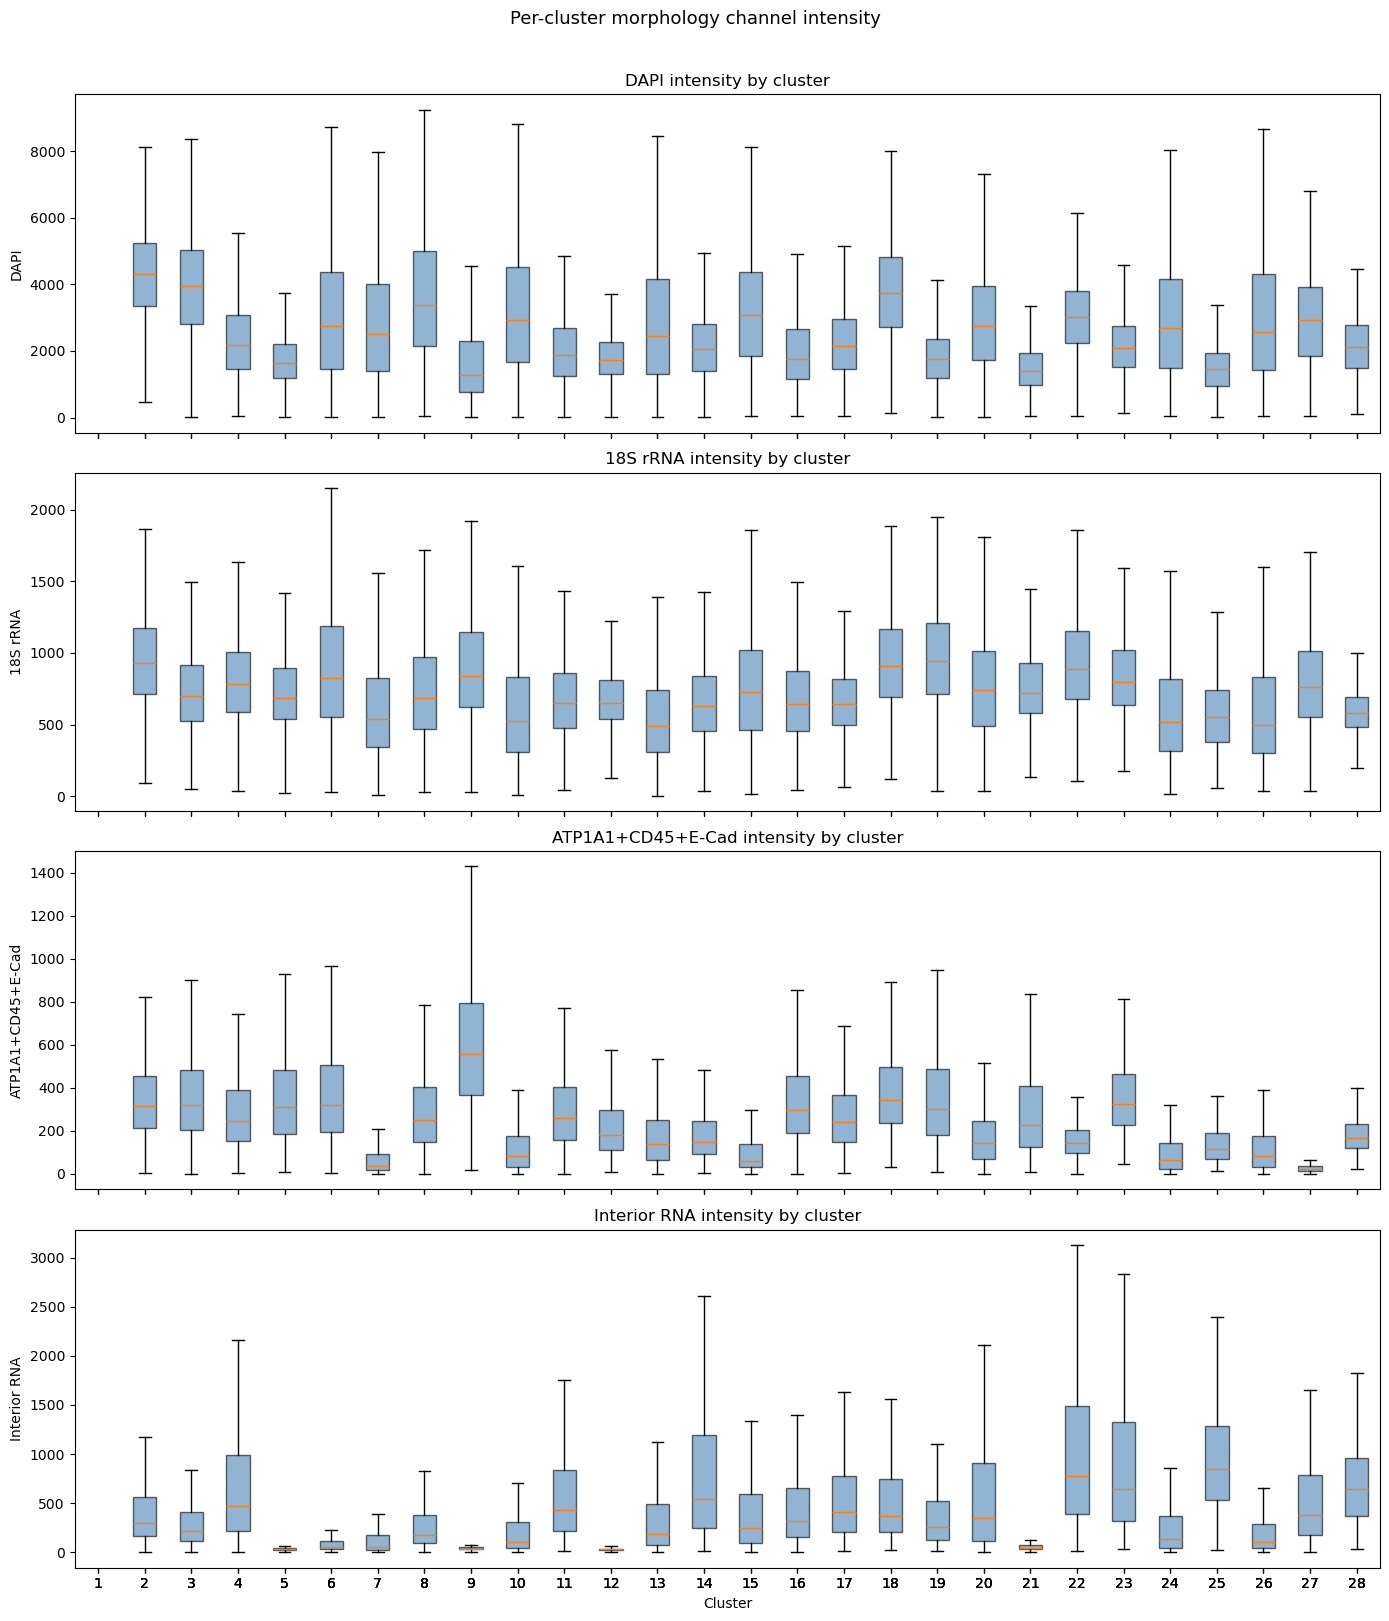

In [25]:
# ── Per-cluster intensity boxplots ─────────────────────────────────
# Clusters with high DAPI = more densely packed nuclei (possibly tumour regions or dense lymphoid areas).
# Clusters with high ATP1A1/CD45/E-Cad = epithelial or immune character.
# Outlier-free boxplots (showfliers=False) keep the plot readable.

n_clusters = len(cluster_names)
fig, axes = plt.subplots(len(channel_names), 1,
                         figsize=(max(12, n_clusters * 0.5), 4 * len(channel_names)),
                         sharex=True)

for ax, ch_name in zip(axes, channel_names):
    col = f"intensity_{ch_name}"
    data_by_cluster = [
        cells_xenium.loc[cells_xenium["cluster"] == k, col].values
        for k in range(1, n_clusters + 1)
    ]
    bp = ax.boxplot(data_by_cluster,
                    labels=[str(k) for k in range(1, n_clusters + 1)],
                    showfliers=False,
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.set_ylabel(ch_name)
    ax.set_title(f"{ch_name} intensity by cluster")

axes[-1].set_xlabel("Cluster")
plt.suptitle("Per-cluster morphology channel intensity", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# ── Select clusters and build a tissue mask ─────────────────────────
# Change SELECTED_CLUSTERS to whichever cluster numbers you want to annotate.
# E.g. after inspecting the boxplots, clusters with high E-Cadherin
# signal are likely epithelial / tumour regions.

SELECTED_CLUSTERS = [4, 8]   # <-- edit these based on the boxplot
LABEL_NAME        = "tumor"  # label used in the export filename

mask_cells = cells_xenium[cells_xenium["cluster"].isin(SELECTED_CLUSTERS)]
print(f"Selected clusters: {SELECTED_CLUSTERS}  ({len(mask_cells):,} cells)")

# Map centroid microns -> downsampled pixel coordinates
col_m = (mask_cells["cell_centroid_x"] / PIXEL_SIZE_DS).astype(int).clip(0, W_ds - 1)
row_m = (mask_cells["cell_centroid_y"] / PIXEL_SIZE_DS).astype(int).clip(0, H_ds - 1)

# 1. Seed mask: mark one pixel per cell centroid
mask_seed = np.zeros((H_ds, W_ds), dtype=bool)
mask_seed[row_m.values, col_m.values] = True
print(f"Seed pixels marked: {mask_seed.sum():,}")

Selected clusters: [4, 8]  (103,538 cells)
Seed pixels marked: 103,538


In [ ]:
# ── Morphological processing to create contiguous regions ──────────
# Cells within a cluster are typically close together but not all touching.
# Strategy:
#   1. Dilate generously to merge nearby cells into one blob
#   2. Fill enclosed holes (interior of dense regions)
#   3. Erode to pull the boundary back inward and smooth edges
#
# Disk radius in pixels; at PIXEL_SIZE_DS=0.425 um/px:
#   disk(12) ~ 5 um radius  |  disk(24) ~ 10 um radius

DILATION_RADIUS = 24   # expand each centroid to fill ~cell diameter
EROSION_RADIUS  = 10   # shrink back to clean up isolated specks

dilated    = skimage.morphology.binary_dilation(mask_seed,
                                                skimage.morphology.disk(DILATION_RADIUS))
filled     = ndi.binary_fill_holes(dilated)
final_mask = skimage.morphology.binary_erosion(filled,
                                               skimage.morphology.disk(EROSION_RADIUS))

print(f"Mask coverage: {final_mask.sum() / final_mask.size * 100:.1f}% of tissue area")

# Visualise over the DAPI image
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(downsampled_ch0, cmap="gray")
axes[0].imshow(final_mask, cmap="Reds", alpha=0.45)
axes[0].set_title(f"Clusters {SELECTED_CLUSTERS} mask overlay on DAPI")
axes[0].axis("off")

axes[1].imshow(downsampled_ch0, cmap="gray")
axes[1].contour(final_mask, levels=[0.5], colors="red", linewidths=0.8)
axes[1].set_title("Mask boundary only")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── Remove small disconnected regions (artifact cleanup) ────────────
# After dilation/erosion, stray blobs can remain:
#   • single-cell islands far from the main cluster
#   • speckling at tissue edges or near artefacts
#
# skimage.morphology.remove_small_objects keeps only connected
# components whose area is >= MIN_REGION_AREA pixels.
#
# Rule of thumb: a single ~10 um cell is ~25 px diameter at PIXEL_SIZE_DS=0.425 um/px
#   → area ~ π*(12)² ≈ 450 px²
# Setting MIN_REGION_AREA = 2000 px² removes anything smaller than ~2 cells.

import skimage.measure

MIN_REGION_AREA = 2000   # px² at downsampled resolution  ← tune this

# Label connected components so we can inspect sizes before filtering
labeled        = skimage.measure.label(final_mask)
props          = skimage.measure.regionprops(labeled)
region_areas   = sorted([r.area for r in props], reverse=True)

print(f"Connected regions before cleanup: {len(region_areas)}")
print(f"5 largest (px²): {region_areas[:5]}")
print(f"5 smallest (px²): {region_areas[-5:]}")

# Remove small objects — returns a new boolean array
final_mask_clean = skimage.morphology.remove_small_objects(final_mask, min_size=MIN_REGION_AREA)

removed = len(region_areas) - skimage.measure.label(final_mask_clean).max()
print(f"\nRegions removed: {removed}")
print(f"Remaining regions: {skimage.measure.label(final_mask_clean).max()}")
print(f"Mask coverage after cleanup: {final_mask_clean.sum() / final_mask_clean.size * 100:.2f}% of tissue area")

# Visualise — original vs. cleaned mask
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(downsampled_ch0, cmap="gray")
axes[0].imshow(final_mask, cmap="Reds", alpha=0.45)
axes[0].set_title("Before artifact removal")
axes[0].axis("off")

axes[1].imshow(downsampled_ch0, cmap="gray")
axes[1].imshow(final_mask_clean, cmap="Reds", alpha=0.45)
axes[1].set_title(f"After removal (min {MIN_REGION_AREA} px²)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── Export mask as TIFF for Xenium Explorer ─────────────────────────
# Xenium Explorer can import custom region annotations.
# The simplest compatible format is a full-resolution binary TIFF where:
#   pixel = 0  → not in region
#   pixel = 255 → in region
#
# We upsample the downsampled mask back to full resolution using
# nearest-neighbour interpolation (order=0) to preserve hard edges.

import skimage.transform

DOWNSAMPLE_FACTOR = 2
fullres_shape = (H_ds * DOWNSAMPLE_FACTOR, W_ds * DOWNSAMPLE_FACTOR)

mask_fullres = skimage.transform.resize(
    final_mask_clean.astype(np.uint8),
    fullres_shape,
    order=0,              # nearest-neighbour — keeps binary values
    preserve_range=True,
    anti_aliasing=False
).astype(np.uint8) * 255

cluster_str = "_".join(str(c) for c in SELECTED_CLUSTERS)
MASK_OUT = os.path.join(
    root_dir,
    "Xenium_Prime_Breast_Cancer_FFPE_xe_outs",
    f"{LABEL_NAME}_clusters_{cluster_str}_mask.tif"
)

tifffile.imwrite(
    MASK_OUT,
    mask_fullres,
    photometric="minisblack",
    resolution=(1 / 0.2125, 1 / 0.2125),   # pixels per micron — tells Explorer the pixel size
    resolutionunit=3,                        # 3 = centimeter; tifffile converts internally
    metadata={"PhysicalSizeX": 0.2125, "PhysicalSizeXUnit": "um",
               "PhysicalSizeY": 0.2125, "PhysicalSizeYUnit": "um"}
)

print(f"Saved: {MASK_OUT}")
print(f"Shape: {mask_fullres.shape}  dtype: {mask_fullres.dtype}")
print()
print("To import into Xenium Explorer:")
print("  File menu -> Import Regions -> select the .tif file")
print("  Set pixel size to 0.2125 um if prompted")

#### Side-by-side comparison of the two extraction approaches

| | MIBI (pixel-label mask) | Xenium (OME-TIFF + CSV/parquet) |
|---|---|---|
| Segment list | `np.unique(seg)[1:]` | `cells_xenium["cell_id"].tolist()` |
| Centroid | `skimage.measure.regionprops(seg)` | `cells_xenium[["x_centroid","y_centroid"]]` |
| Pixel membership | `np.where(seg == cell_id)` | `rasterize()` a boundary polygon |
| Area | `p.area` (pixels) | `cells_xenium["cell_area"]` (µm²) |
| Spatial units | pixels | microns |

---
## 4. Tissue region masks — assigning cells to tumor / peritumoral / extratumoral

A tissue region TIF encodes distinct anatomical regions as integer pixel values.  
We extract per-region boolean masks and convert them to Shapely polygons, then use
point-in-polygon tests (or a direct pixel lookup) to label each cell.

> **Note:** a region annotation TIF is not included in this demo dataset.  
> The code below uses a synthetic toy example to demonstrate the workflow; swap in your real region TIF path to run it on actual data.

In [35]:
# ── Synthetic region image sized to match MIBI segmentation ─────────
# In practice: region_img = skio.imread(REGION_TIF, plugin="tifffile")
H, W = seg.shape
region_img = np.zeros((H, W), dtype=np.uint8)
# Tumor core: central rectangle
region_img[H//4:3*H//4, W//4:3*W//4] = 1
# Peritumoral margin: a band around the tumor
import skimage.morphology as morph
tumor_dilated = morph.binary_dilation(
    region_img == 1,
    morph.disk(H // 12)
)
region_img[tumor_dilated & (region_img == 0)] = 2

print("Unique region values:", np.unique(region_img))

Unique region values: [0 1 2]


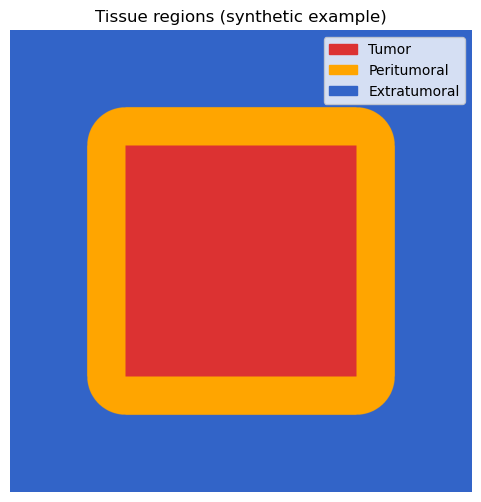

In [36]:
# Boolean masks per region
tumor_mask      = region_img == 1
peritumor_mask  = region_img == 2
extratumor_mask = region_img == 0

# Colour overlay
overlay = np.zeros((H, W, 3), dtype=np.uint8)
overlay[tumor_mask]      = [220,  50,  50]   # red
overlay[peritumor_mask]  = [255, 165,   0]   # orange
overlay[extratumor_mask] = [ 50, 100, 200]   # blue

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(overlay)
ax.set_title("Tissue regions (synthetic example)")
ax.axis("off")
patches = [
    mpatches.Patch(color=[220/255,  50/255,  50/255], label="Tumor"),
    mpatches.Patch(color=[255/255, 165/255,   0/255], label="Peritumoral"),
    mpatches.Patch(color=[ 50/255, 100/255, 200/255], label="Extratumoral"),
]
ax.legend(handles=patches, loc="upper right")
plt.show()

In [37]:
# ── Convert masks to Shapely polygons ───────────────────────────────
def mask_to_polygons(binary_mask):
    """Trace contours of a boolean mask → list of valid Shapely Polygons."""
    padded = binary_mask.copy().astype(float)
    padded[0, :] = padded[-1, :] = padded[:, 0] = padded[:, -1] = 0
    polygons = []
    for contour in skimage.measure.find_contours(padded):
        poly = geom.Polygon(np.flip(contour, axis=1))  # (row,col) → (x,y)
        if poly.is_valid and poly.area > 0:
            polygons.append(poly)
    return polygons

tumor_region    = unary_union(mask_to_polygons(tumor_mask))
peritumor_region = unary_union(mask_to_polygons(peritumor_mask))

print("Tumor polygon(s) area:", round(tumor_region.area))
print("Peritumoral polygon(s) area:", round(peritumor_region.area))

Tumor polygon(s) area: 1048576
Peritumoral polygon(s) area: 1835000


In [ ]:
# ── Option 1: Shapely point-in-polygon test ──────────────────────────
# Good when polygons came from an external annotation tool (QuPath, etc.)

def assign_region_shapely(x, y):
    pt = geom.Point(x, y)
    if tumor_region.contains(pt):
        return "tumor"
    elif peritumor_region.contains(pt):
        return "peritumoral"
    return "extratumoral"

# ── Option 2: Direct pixel lookup ───────────────────────────────────
# Fast when you already have a region TIF with integer labels
REGION_LABELS = {1: "tumor", 2: "peritumoral", 0: "extratumoral"}

def assign_region_pixel(x, y):
    row = int(round(y))
    col = int(round(x))
    return REGION_LABELS.get(region_img[row, col], "extratumoral")


# Apply pixel-lookup (fast) to MIBI cells
cells_mibi["region"] = [
    assign_region_pixel(row.centroid_x, row.centroid_y)
    for _, row in cells_mibi.iterrows()
]

print(cells_mibi["region"].value_counts())

In [ ]:
# Visualise: centroids coloured by region
region_colors = {"tumor": "red", "peritumoral": "orange", "extratumoral": "steelblue"}

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(overlay, alpha=0.35)

for region_name, group in cells_mibi.groupby("region"):
    ax.scatter(
        group["centroid_x"], group["centroid_y"],
        s=3, c=region_colors[region_name], label=region_name, alpha=0.7
    )

ax.set_title("MIBI cell centroids coloured by region")
ax.axis("off")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

---
## Summary

| Step | Key function | Output |
|---|---|---|
| Load MIBI multilayer TIF | `skio.imread_collection(..., plugin="tifffile")` | 3-D array (channels x H x W) |
| Load MIBI segmentation mask | `skio.imread(..., plugin="tifffile")` | 2-D integer array (H x W) |
| Load Xenium OME-TIFF (one channel, downsampled) | `tifffile.imread(..., is_ome=False, level=1)` | 2-D array |
| Load Xenium OME-TIFF (all channels, full res) | `tifffile.imread(..., is_ome=True, level=0)` | 3-D array (channels x H x W) — slow |
| Get MIBI marker names | `page.tags['PageName'].value` | list of channel name strings |
| Get Xenium channel names | parse `tif.ome_metadata` XML | list of channel name strings |
| **Extract MIBI segment list** | `np.unique(seg)[1:]` | array of cell IDs |
| **Extract MIBI centroids/area** | `skimage.measure.regionprops(seg)` | list of region property objects |
| **Open Xenium zarr bundle** | `zarr.ZipStore("cells.zarr.zip")` + `zarr.open_group()` | zarr Group object |
| **Extract Xenium segment list** | `cells_z["cell_id"][:]` | (n_cells, 2) uint32 array |
| **Extract Xenium centroids/area** | `cells_z["cell_summary"][:]` | (n_cells, 8) float64 array |
| **Extract Xenium cell polygons** | `cells_z["polygon_sets/1/vertices"][:]` | (n_cells, 50) float32 — 25 (x,y) pairs per cell |
| Extract region mask | `region_img == value` | boolean 2-D array |
| Assign cell to region (fast) | `region_img[row, col]` | region label |
| Assign cell to region (polygon) | `polygon.contains(Point(x, y))` | region label |